In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras.optimizers import SGD

In [11]:
# 1. Fetching and loading the dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, header=None, names=columns)

### About the dataset

- Pima Indian Diabetes Dataset
- Originally from the National Institute of Diabetes and Digestive and Kidney Diseases
- Contains information of 768 women from a population near Phoenix, Arizona, USA
- Outcome tested was Diabetes
- 258 tested positive and 500 tested negative
- One target (dependent) variable
- The 8 attributes: pregnancies, OGTT(Oral Glucose Tolerance Test), blood pressure, skin thickness, insulin, BMI(Body Mass Index), age, pedigree diabetes function
- The Pima population has been under study by the National Institute of Diabetes and Digestive and Kidney Diseases at intervals of 2 years since 1965
- Pima Indians Diabetes Dataset includes information about attributes that could be related to the onset of diabetes and its future complications

In [12]:
# 2. Examining the dataset

data.sample(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
348,3,99,62,19,74,21.8,0.279,26,0
377,1,87,60,37,75,37.2,0.509,22,0
414,0,138,60,35,167,34.6,0.534,21,1


In [13]:
# 3. Separating inputs and output
# The values attribute applied on a dataframe returns a numpy array

X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values

In [14]:
# 4. Split the dataset randomly

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# 5. Standardize the features

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [16]:
X_train_std_final, X_val_std, y_train_final, y_val = train_test_split(X_train_std, y_train, test_size=0.2, random_state=42)

In [17]:
print(f"Training input shape is {X_train_std.shape}")
print(f"Testing input shape is {X_test_std.shape}")

Training input shape is (614, 8)
Testing input shape is (154, 8)


In [29]:
# 6. Building a Multi Layered Perceptron

# Layers are arranged linearly; one after another
model = Sequential()

# Defining the input layer explicitly with shape matching the number of features
model.add(Input(shape=(X_train_std.shape[1],)))

# Adding subsequent layers

# First hidden layer connected directly with the input layer
# Need to mention the input dimension (number of features / columns)
model.add(Dense(16))

model.add(Activation('relu'))

model.add(Dense(32))

model.add(Activation('relu')) 

model.add(Dense(64))

model.add(Activation('relu'))  # Activation function for non-linearity detection


# Second hidden layer with 32 neurons
# Input to this layer comes from output of first hidden layer
model.add(Dense(32))

model.add(Activation('relu'))  # ReLu = rectified linear unit


# Third hidden layer with 16 neurons
# Input dimension is automatically inferred
model.add(Dense(16))

model.add(Activation('relu'))

# Output layer with 1 neuron
model.add(Dense(1))

model.add(Activation('sigmoid'))  # Activation function for binary classification

The comma after `X_train.shape[1]` in `Input(shape=(X_train.shape[1],))` is significant because it indicates that the `shape` parameter is a tuple.

### **Details:**
- `X_train.shape[1]` gives the number of features (columns) in the training data.
- By writing `(X_train.shape[1],)` with a trailing comma, we create a **tuple with one element**. This is important because `shape` expects a tuple, even if it has only one dimension.

### **Why is the Comma Necessary?**
- In Python, `(X_train.shape[1])` is interpreted as a single value (not a tuple).
- Adding a comma makes it a tuple: `(X_train.shape[1],)`.

### **Example:**
```python
a = (5)        # Not a tuple, it's just an integer.
b = (5,)       # This is a tuple with one element.
```

### **Relevance to Keras**
The input `shape` parameter must always be specified as a tuple. For instance:
- If our input data has 10 features, `shape=(10,)` tells Keras the model expects 10-dimensional input vectors.
- If we are working with higher-dimensional data (e.g., images), the tuple may look like `(height, width, channels)`.

In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              17 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_15 (Activation)           │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,425 (21.19 KB)

 Trainable params: 5,425 (21.19 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Step 7: Compiling the model
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [33]:
# Step 8: Training the model
history = model.fit(X_train_std, y_train, epochs=20, batch_size=32, validation_split=0.3, verbose=1)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7529 - loss: 0.5231 - val_accuracy: 0.7135 - val_loss: 0.5426
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7529 - loss: 0.5202 - val_accuracy: 0.7351 - val_loss: 0.5399
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7622 - loss: 0.5170 - val_accuracy: 0.7297 - val_loss: 0.5375
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7646 - loss: 0.5142 - val_accuracy: 0.7297 - val_loss: 0.5351
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7599 - loss: 0.5115 - val_accuracy: 0.7297 - val_loss: 0.5330
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7692 - loss: 0.5086 - val_accuracy: 0.7297 - val_loss: 0.5310
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7669 - loss: 0.5055 - val_accuracy: 0.7405 - val_loss: 0.5286
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7669 - loss: 0.5029 - val_accuracy: 0.7459 - v

In [34]:
# Step 8: Training the model
#history = model.fit(X_train_std, y_train, epochs=10, batch_size=32, validation_data=(X_val_std, y_val), verbose=1)

In [35]:
type(history.history)

dict

In [36]:
df=pd.DataFrame(history.history)

In [37]:
# Step 9: Evaluate the model
loss, accuracy = model.evaluate(X_test_std, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7468 - loss: 0.5186 
Test Accuracy: 0.75


In [38]:
# 10. Visualizing the results
import matplotlib.pyplot as plt

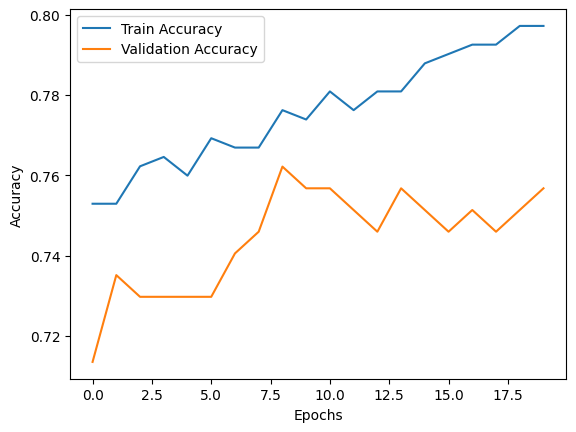

In [39]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

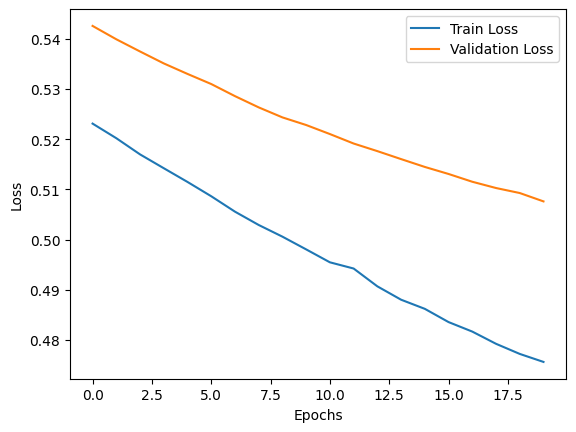

In [40]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
df

,accuracy,loss,val_accuracy,val_loss
0,0.752914,0.523094,0.713513,0.542559
1,0.752914,0.520185,0.735135,0.539897
2,0.762238,0.516959,0.729730,0.537464
3,0.764569,0.514204,0.729730,0.535088
4,0.759907,0.511468,0.729730,0.532993
5,0.769231,0.508618,0.729730,0.530980
6,0.766900,0.505548,0.740541,0.528569
7,0.766900,0.502892,0.745946,0.526326
8,0.776224,0.500565,0.762162,0.524331
9,0.773893,0.498028,0.756757,0.522812


### Observation

We see that:

    1. By increaing the number of layers we and the nurons we give the model to learn more about the train data but excessively incresing the neurons i.e introducing a layer with 128 nurons causes the model to ovefit
    2. By increaing the epoch we allow the model to do more updation in the weights and biases but if we increase the learning rate from 0.001 to 0.01 we see that the updates occur more frequently and we see drop in loss in each epoch but setting the leaerning rate as high as 1.0 we see theat the loss oscillates and not actually decreases
    3. By increasing the epoch as we see that in 10 epochs we see that the loss continues to decrease and by increasing it to 20 epoch the loss almost stagnates.